In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

# Data Preprocessing

### Training image Preprocessing

In [2]:
#load dataset
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=True
)

validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

print("Class Names:", training_set.class_names)

Found 7000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Class Names: ['fake', 'real']


In [3]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [4]:
validation_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
training_set = training_set.map(lambda x, y: (normalization_layer(x), y))
validation_set = validation_set.map(lambda x, y: (normalization_layer(x), y))


In [6]:
training_set

<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [7]:
validation_set

<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = np.concatenate([y.numpy() for x, y in training_set], axis=0)
labels = np.argmax(labels, axis=1)  # one-hot to index

class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: 1.0, 1: 1.0}


# Building Model

In [9]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential


In [10]:
model=Sequential()

In [11]:
## Building convolutional Layer

In [12]:
model.add(Conv2D(filters=32,kernel_size=3,padding="same",activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

c:\Users\Gopal Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.add(Conv2D(filters=64,kernel_size=3,padding="same",activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=128,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(Conv2D(filters=256,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [16]:
model.add(Conv2D(filters=512,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [17]:
model.add(Dropout(0.25)) ## To Avoid overfitting

In [18]:
model.add(Flatten())

In [19]:
model.add(Dense(units=128,activation='relu'))

In [20]:
model.add(Dropout(0.5))

In [21]:
## output layer
# here 2 different class problem so we are neend to here 2 different outputs
# softmax neuron gives the probability of each class in each neurons
model.add(Dense(units=2,activation='softmax' ))

## Compiling the model

In [22]:
## here we are dicrease the learning rate becase of minimize the loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

In [23]:
# training_history=model.fit(x=training_set,validation_data=validation_set,epochs=15)

training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    class_weight=class_weights
)



Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.4958 - loss: 0.6933 - val_accuracy: 0.5253 - val_loss: 0.6927
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.5105 - loss: 0.6928 - val_accuracy: 0.5080 - val_loss: 0.6931
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.5101 - loss: 0.6936 - val_accuracy: 0.5133 - val_loss: 0.6928
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.5352 - loss: 0.6893 - val_accuracy: 0.5227 - val_loss: 0.6916
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.5605 - loss: 0.6819 - val_accuracy: 0.6023 - val_loss: 0.6702
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 219s 1000ms/step - accuracy: 0.5984 - loss: 0.6662 - val_accuracy: 0.6217 - val_loss: 0.6484
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.6379 - loss: 0.6409 - val_accuracy: 0.6230 - val_loss: 0.6451
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.6668 - loss: 0.6248 - val_

In [44]:
labels = np.concatenate([y.numpy() for x,y in training_set], axis=0)
labels = np.argmax(labels, axis=1)

unique, counts = np.unique(labels, return_counts=True)
print("Training Class Distribution:", dict(zip(unique, counts)))

Training Class Distribution: {0: 3500, 1: 3500}


In [24]:

labels = np.concatenate([y.numpy() for x,y in validation_set], axis=0)
labels = np.argmax(labels, axis=1)

unique, counts = np.unique(labels, return_counts=True)
print("Validation Class Distribution:", dict(zip(unique, counts)))


Validation Class Distribution: {0: 1500, 1: 1500}


### Model evaluation

In [25]:
## Model Evaluation on Training set
train_loss,train_acc=model.evaluate(training_set)

print(train_loss,train_acc)

219/219 ━━━━━━━━━━━━━━━━━━━━ 37s 168ms/step - accuracy: 0.9633 - loss: 0.0887
0.07797826826572418 0.9692857265472412


In [26]:
## Model evaluation on validation set
val_loss,val_acc=model.evaluate(validation_set)

print(val_loss,val_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.8008 - loss: 0.7561
0.7897434234619141 0.7916666865348816


### Saving Model

In [27]:
model.save("Trained_model.h5")

In [28]:
model.save("Trained_model.keras")

In [29]:
training_history.history

{'accuracy': [0.4998571574687958,
  0.5090000033378601,
  0.520714282989502,
  0.5377143025398254,
  0.5731428861618042,
  0.6091428399085999,
  0.6375714540481567,
  0.6675714254379272,
  0.7034285664558411,
  0.7350000143051147,
  0.7620000243186951,
  0.7897142767906189,
  0.8172857165336609,
  0.845714271068573,
  0.8820000290870667,
  0.9007142782211304,
  0.9214285612106323,
  0.9458571672439575,
  0.9554286003112793,
  0.9674285650253296],
 'loss': [0.6928316354751587,
  0.6927481293678284,
  0.6933279037475586,
  0.6881251335144043,
  0.6788588166236877,
  0.6603568196296692,
  0.6404666304588318,
  0.6173925995826721,
  0.579628050327301,
  0.5332894325256348,
  0.497761070728302,
  0.4553638994693756,
  0.4109462797641754,
  0.35766834020614624,
  0.2974332571029663,
  0.2500118017196655,
  0.20143288373947144,
  0.1477232277393341,
  0.1145486831665039,
  0.08474940061569214],
 'val_accuracy': [0.5253333449363708,
  0.5080000162124634,
  0.5133333206176758,
  0.5226666927337

In [30]:
## Recording history in json Formate
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [31]:
training_history.history['accuracy']

[0.4998571574687958,
 0.5090000033378601,
 0.520714282989502,
 0.5377143025398254,
 0.5731428861618042,
 0.6091428399085999,
 0.6375714540481567,
 0.6675714254379272,
 0.7034285664558411,
 0.7350000143051147,
 0.7620000243186951,
 0.7897142767906189,
 0.8172857165336609,
 0.845714271068573,
 0.8820000290870667,
 0.9007142782211304,
 0.9214285612106323,
 0.9458571672439575,
 0.9554286003112793,
 0.9674285650253296]

In [32]:
training_history.history['val_accuracy']

[0.5253333449363708,
 0.5080000162124634,
 0.5133333206176758,
 0.5226666927337646,
 0.6023333072662354,
 0.621666669845581,
 0.6230000257492065,
 0.5809999704360962,
 0.6773333549499512,
 0.7170000076293945,
 0.7333333492279053,
 0.7400000095367432,
 0.7580000162124634,
 0.7773333191871643,
 0.7826666831970215,
 0.7749999761581421,
 0.7940000295639038,
 0.7680000066757202,
 0.8013333082199097,
 0.7916666865348816]

### Accurary Visualization

In [33]:
epochs=[i for i in range(1,21)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

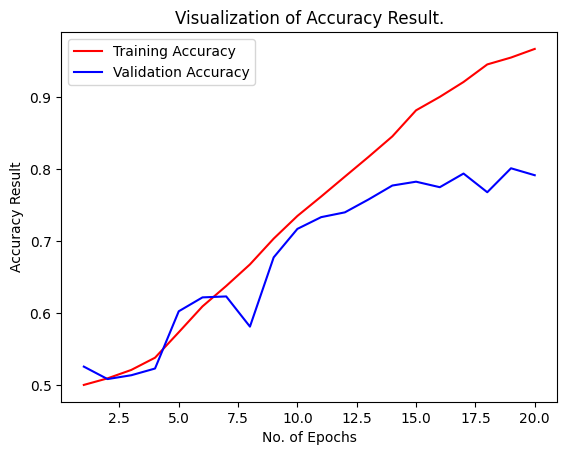

In [34]:
plt.plot(epochs,training_history.history['accuracy'],color='Red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result.")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [35]:
# class_name=validation_set.class_names
# class_name

In [36]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 3000 files belonging to 2 classes.


In [37]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step


In [38]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [39]:
Y_true

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int64)>

In [40]:
predicted_categories

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 1, 1, ..., 1, 1, 1], dtype=int64)>

In [41]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [42]:
# # Precision Recall Fscore
# print(classification_report(Y_true,predicted_categories,target_names=class_name))

### Confusion matrix visualization

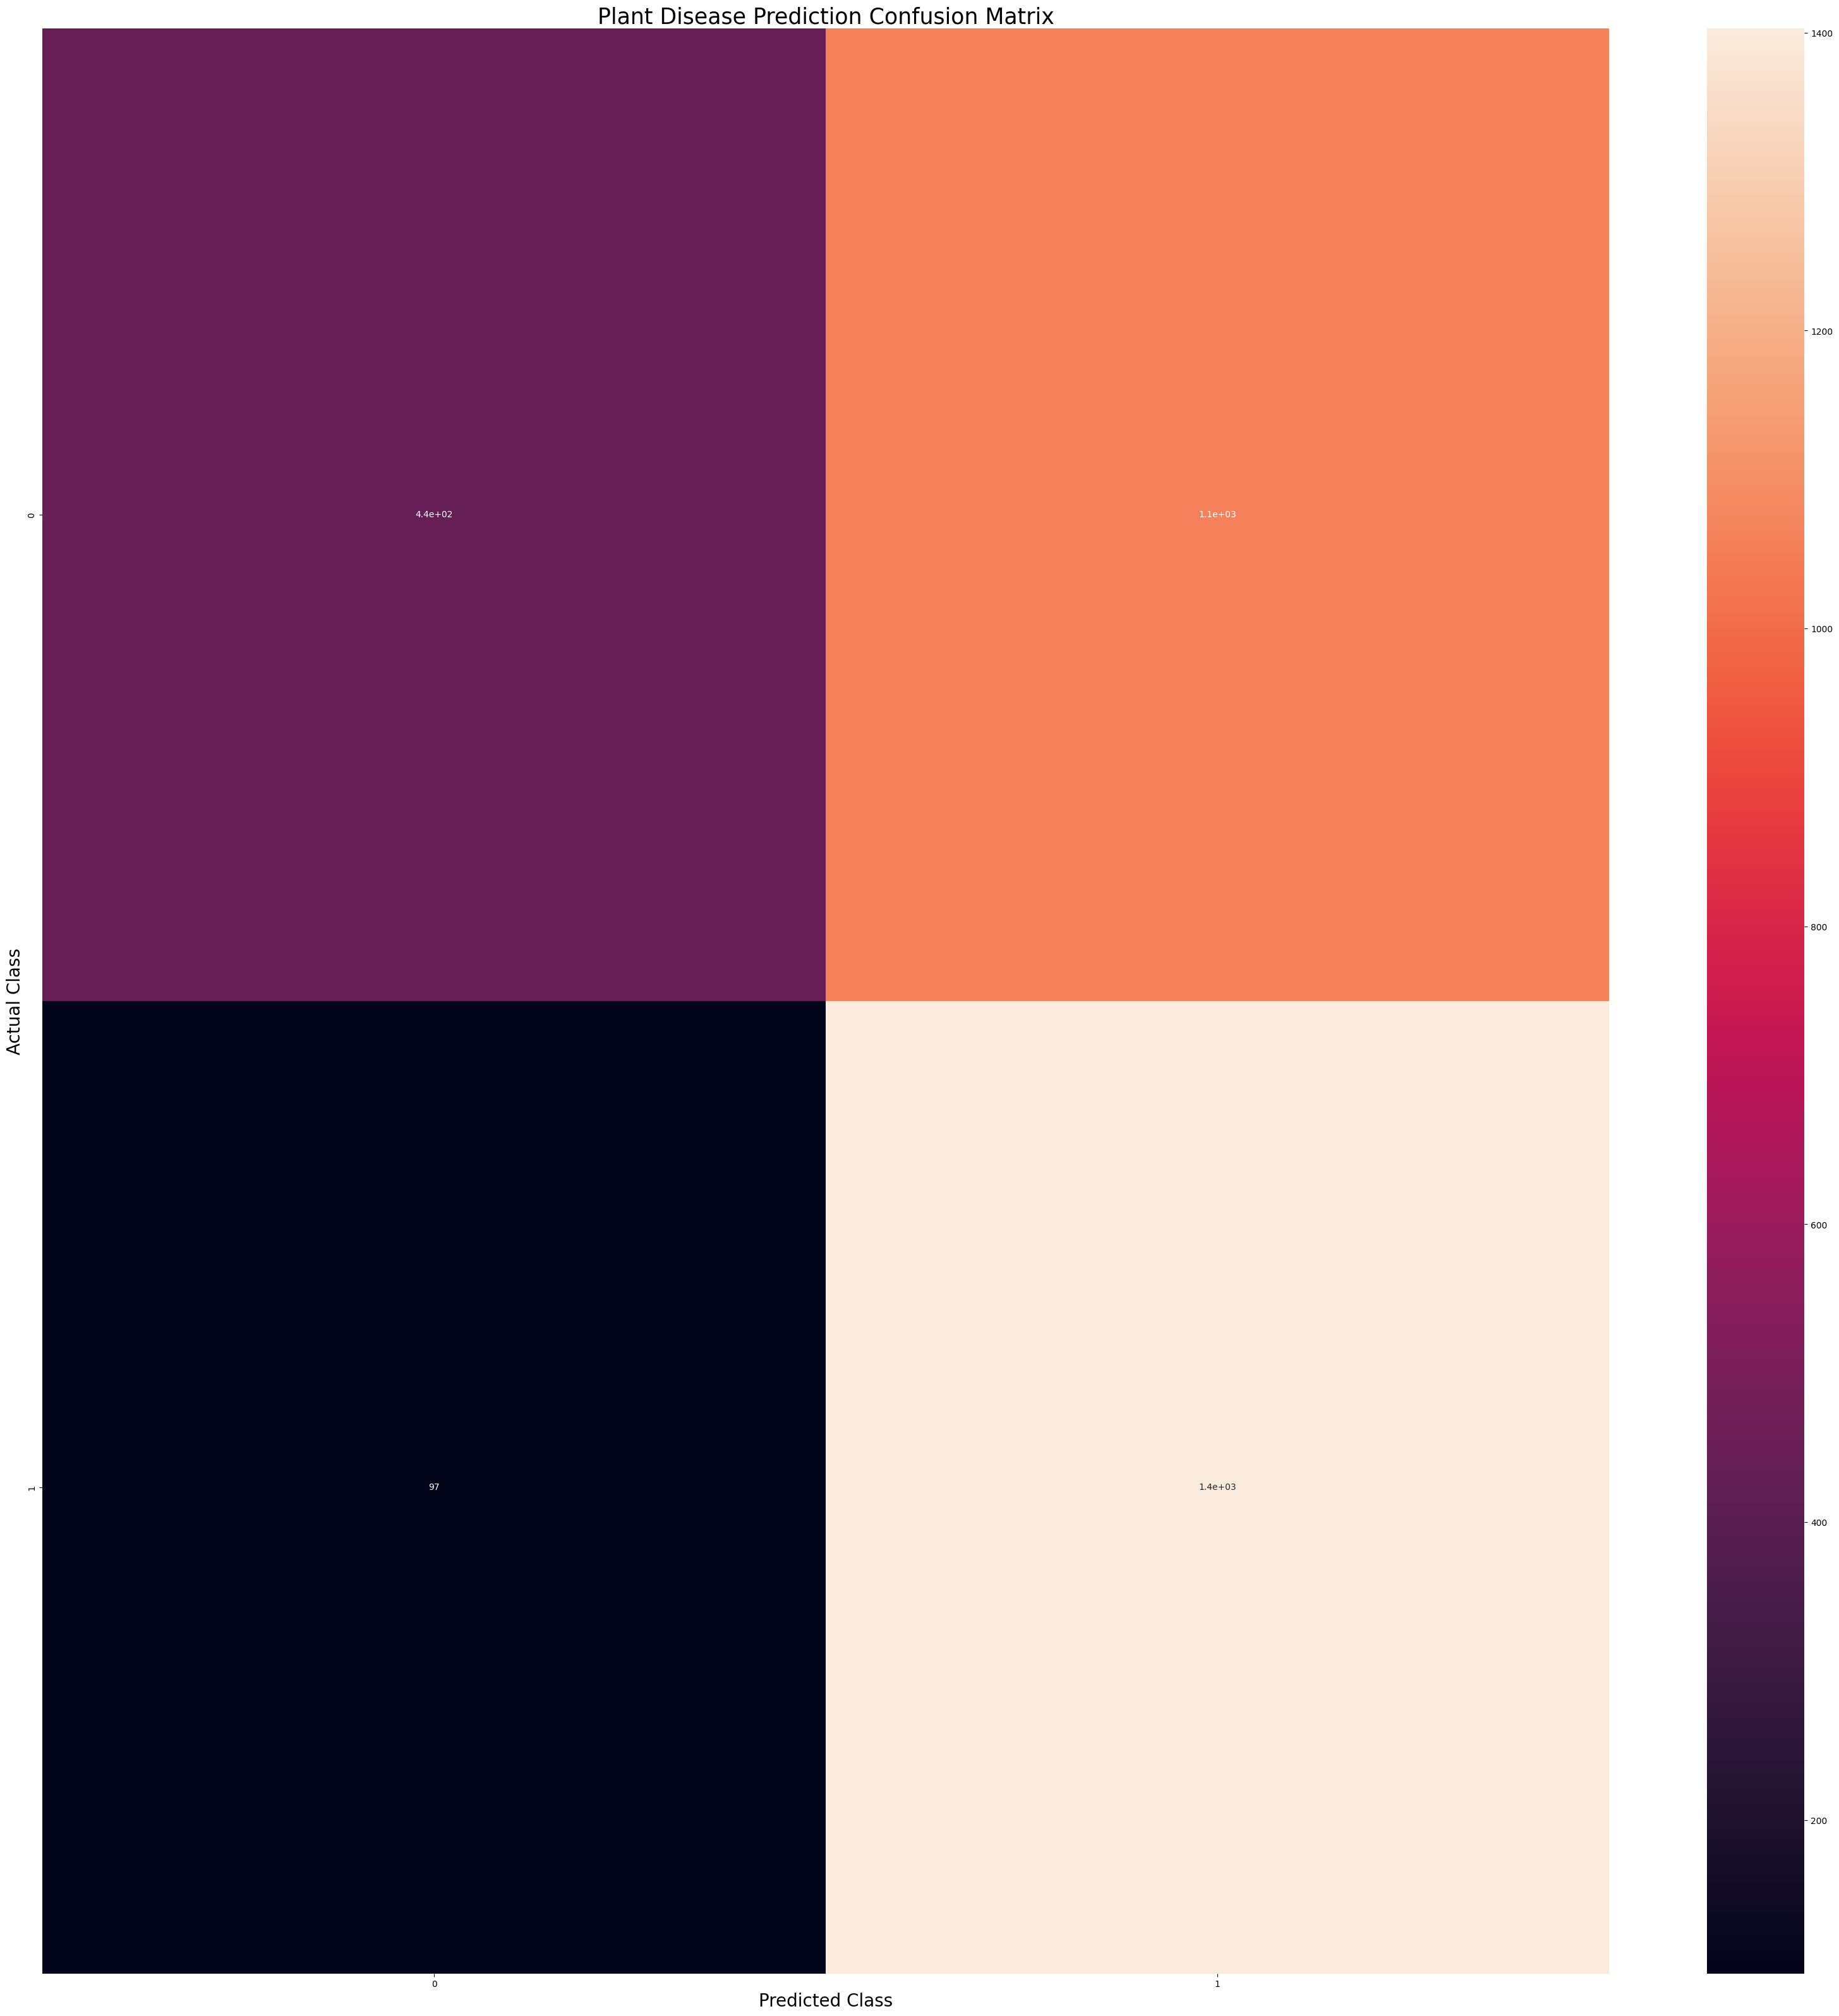

In [43]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()